In [1]:
# === Upgrade Java to version 21 for SPMF compatibility ===
!apt-get update -y
!apt-get install -y openjdk-21-jdk
!java -version

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,951 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:14 https://r2u.stat.il

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk-amd64"
os.environ["PATH"] += os.pathsep + "/usr/lib/jvm/java-21-openjdk-amd64/bin"

In [4]:
# ============================================================
# E(3A)CSPM: Employee Attrition Prediction using SPM
# Case 1: with & without SMOTE
# Case 2: Sequential Pattern Features (TKS + ERMiner)
# ============================================================

import pandas as pd, numpy as np, os, subprocess, time
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# ---------- Helper: download SPMF ----------
def download_spmf():
    if not os.path.exists("spmf.jar"):
        print("Downloading SPMF...")
        subprocess.run(["wget","-q","-O","spmf.jar",
                        "http://www.philippe-fournier-viger.com/spmf/spmf.jar"])
        print("SPMF downloaded")
    else:
        print("SPMF already exists")

# ---------- Load & preprocess ----------
def load_dataset(path, target_col):
    df = pd.read_csv(path)
    print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} cols")
    df = df.fillna("Unknown").astype(str)
    return df, target_col

# ---------- Build SPMF sequences ----------
def create_mapping(df):
    mapping = {}
    idx=1
    for col in df.columns:
        for v in df[col].unique():
            mapping[(col,v)] = idx; idx+=1
    print(f"Created mapping with {len(mapping)} unique items")
    return mapping

def to_spmf(df, mapping, filename):
    seqs=[]
    for _,r in df.iterrows():
        s=[]; prev=None
        for c in df.columns:
            item=mapping[(c,r[c])]
            if item!=prev:
                s.append(str(item)); s.append("-1"); prev=item
        s.append("-2"); seqs.append(" ".join(s))
    with open(filename,"w") as f: f.write("\n".join(seqs))
    print(f"Saved {len(seqs)} sequences → {filename}")

# ---------- Run SPMF algorithms ----------
def run_tks(inp,out,k=500):
    print(f"Running TKS (k={k})")
    res=subprocess.run(["java","-Xmx4g","-jar","spmf.jar","run","TKS",inp,out,str(k)],
                       capture_output=True,text=True)
    print("TKS completed" if res.returncode==0 else f" TKS failed: {res.stderr}")

def run_erminer(inp,out,minsup="50%",minconf="60%"):
    print(f"Running ERMiner (minsup={minsup}, minconf={minconf})")
    res=subprocess.run(["java","-Xmx4g","-jar","spmf.jar","run","ERMiner",
                        inp,out,minsup,minconf],capture_output=True,text=True)
    print("ERMiner completed" if res.returncode==0 else f" ERMiner failed: {res.stderr}")

# ---------- Common model dictionary ----------
def model_dict():
    return {
        "MNB": MultinomialNB(alpha=1.0),
        "GNB": GaussianNB(),
        "DT": DecisionTreeClassifier(random_state=42),
        "RF": RandomForestClassifier(n_estimators=100,random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(600,),activation='tanh',
                             solver='adam',max_iter=2000,random_state=42),
        "SVM": SVC(C=1,kernel='rbf',gamma='scale',random_state=42),
        "kNN": KNeighborsClassifier(n_neighbors=2,metric='euclidean'),
        "LR": LogisticRegression(max_iter=500,random_state=42)
    }

# ============================================================
# CASE 1 — All Features (With and Without SMOTE)
# ============================================================
def case1(df,target,dataset):
    print(f"\n{'='*60}\nCASE 1: {dataset} – All Features\n{'='*60}")
    df=df.copy()
    le=LabelEncoder()
    for c in df.select_dtypes(include='object').columns:
        if c!=target: df[c]=le.fit_transform(df[c])
    df[target]=le.fit_transform(df[target])
    X=df.drop(columns=[target]); y=df[target]
    X=MinMaxScaler().fit_transform(X)

    models=model_dict(); cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

    print("\n Without SMOTE (10-fold CV)")
    for n,m in models.items():
        t=time.time()
        sc=cross_val_score(m,X,y,cv=cv,scoring='accuracy')
        print(f"{n}: {sc.mean()*100:.2f}% ({time.time()-t:.2f}s)")

    print("\n With SMOTE (10-fold CV)")
    for n,m in models.items():
        scores=[]; t=time.time()
        for tr,ts in cv.split(X,y):
            Xtr,Xts=X[tr],X[ts]; ytr,yts=y.iloc[tr],y.iloc[ts]
            Xres,yres=SMOTE(random_state=42).fit_resample(Xtr,ytr)
            m.fit(Xres,yres)
            scores.append(m.score(Xts,yts))
        print(f"{n}: {np.mean(scores)*100:.2f}% ({time.time()-t:.2f}s)")

# ============================================================
# CASE 2 — Sequential Pattern Features (Top-k TKS Patterns)
# ============================================================
def parse_tks(file):
    pats=[]
    if not os.path.exists(file): return pats
    for line in open(file):
        if "#SUP:" in line:
            p,s=line.split("#SUP:")
            items=[int(x) for x in p.split() if x not in ["-1","-2",""]]
            if len(items)>=2: pats.append(items)
    print(f"Parsed {len(pats)} patterns from {file}")
    return pats[:100]   # top 100 patterns

def pattern_features(df,mapping,patterns,target):
    rev={v:(c,val) for (c,val),v in mapping.items()}
    df_s=df.astype(str); n=len(df)
    mat=np.zeros((n,len(patterns)),dtype=np.int8)
    for i,p in enumerate(patterns):
        pairs=[rev[x] for x in p if x in rev]
        for r in range(n):
            if all(df_s.iloc[r][c]==val for c,val in pairs): mat[r,i]=1
    feat=pd.DataFrame(mat,columns=[f"P{i+1}" for i in range(len(patterns))])
    feat[target]=df[target].values
    print(f"Pattern feature matrix: {feat.shape}")
    return feat

def case2(df,mapping,patterns,target,dataset):
    print(f"\n{'='*60}\nCASE 2: {dataset} – Sequential Pattern Features\n{'='*60}")
    dfp=pattern_features(df,mapping,patterns,target)
    X=dfp.drop(columns=[target]); y=LabelEncoder().fit_transform(dfp[target])
    X=MinMaxScaler().fit_transform(X)
    models=model_dict(); cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
    for n,m in models.items():
        t=time.time(); sc=cross_val_score(m,X,y,cv=cv,scoring='accuracy')
        print(f"{n}: {sc.mean()*100:.2f}% ({time.time()-t:.2f}s)")

# ============================================================
# MAIN
# ============================================================
def main():
    download_spmf()

    # ---------- IBM ----------
    df_ibm,target_ibm=load_dataset("WA_Fn-UseC_-HR-Employee-Attrition.csv","Attrition")
    df_ibm= df_ibm.drop(columns=['EmployeeCount', 'Over18', 'StandardHours','EmployeeNumber'])
    mapping_ibm=create_mapping(df_ibm)
    to_spmf(df_ibm,mapping_ibm,"ibm_spmf_input.txt")
    run_tks("ibm_spmf_input.txt","ibm_tks.txt")
    run_erminer("ibm_spmf_input.txt","ibm_rules.txt")
    case1(df_ibm,target_ibm,"IBM")
    pats_ibm=parse_tks("ibm_tks.txt")
    if pats_ibm: case2(df_ibm,mapping_ibm,pats_ibm,target_ibm,"IBM")

    print("\nAll evaluations complete!")

# ============================================================
if __name__=="__main__":
    main()


SPMF already exists
Loaded WA_Fn-UseC_-HR-Employee-Attrition.csv: 1470 rows, 35 cols
Created mapping with 4033 unique items
Saved 1470 sequences → ibm_spmf_input.txt
Running TKS (k=500)
TKS completed
Running ERMiner (minsup=50%, minconf=60%)
ERMiner completed

CASE 1: IBM – All Features

 Without SMOTE (10-fold CV)
MNB: 83.88% (0.07s)
GNB: 84.29% (0.05s)
DT: 78.71% (0.24s)
RF: 85.58% (3.11s)
MLP: 86.87% (28.31s)
SVM: 86.39% (0.47s)
kNN: 83.88% (0.08s)
LR: 86.87% (0.13s)

 With SMOTE (10-fold CV)
MNB: 74.22% (0.10s)
GNB: 72.11% (0.08s)
DT: 78.23% (0.47s)
RF: 86.12% (6.44s)
MLP: 76.87% (37.73s)
SVM: 82.99% (1.31s)
kNN: 75.58% (0.07s)
LR: 75.51% (0.17s)
Parsed 461 patterns from ibm_tks.txt

CASE 2: IBM – Sequential Pattern Features
Pattern feature matrix: (1470, 101)
MNB: 98.78% (0.03s)
GNB: 99.86% (0.04s)
DT: 99.25% (0.10s)
RF: 99.59% (1.95s)
MLP: 99.66% (38.75s)
SVM: 99.32% (0.29s)
kNN: 96.19% (0.07s)
LR: 99.59% (0.10s)

All evaluations complete!


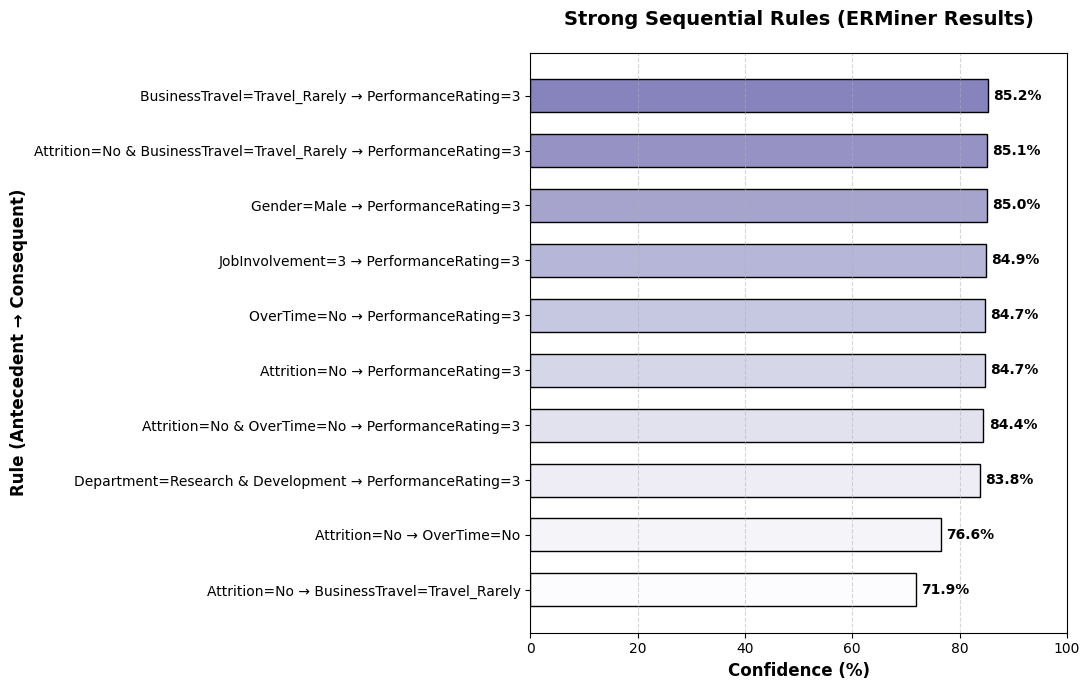

In [3]:
# ============================================================
# 1. Parse ERMiner Rules + Decode with Real Feature Names
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load IBM Dataset to Build Feature → ID Mapping ---
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], errors='ignore')

# Build (feature, value) → ID mapping
FEATURE_TO_ID = {}
current_id = 1
for col in df.columns:
    for val in df[col].unique():
        key = f"{col}_{val}"
        FEATURE_TO_ID[key] = current_id
        current_id += 1

# Reverse: ID → (col, val)
ID_TO_FEATURE = {v: k for k, v in FEATURE_TO_ID.items()}

# --- Parse ERMiner Rules ---
def parse_erminer_rules(file_path):
    rules = []
    with open(file_path, 'r') as f:
        for line in f:
            if '#SUP:' in line and '#CONF:' in line:
                parts = line.strip().split(' ==> ')
                if len(parts) != 2: continue
                antecedent_str, rest = parts
                consequent_str, sup_conf = rest.split('#SUP:')
                sup_part, conf_part = sup_conf.split('#CONF:')

                antecedent = [int(x) for x in antecedent_str.split(',') if x.strip().isdigit()]
                consequent = [int(x) for x in consequent_str.split() if x.strip().isdigit()]
                support = int(sup_part.strip())
                confidence = float(conf_part.strip())

                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent,
                    'support': support,
                    'confidence': confidence
                })
    return rules

# --- Decode Rule into Human Readable ---
def decode_rule(antecedent_ids, consequent_ids):
    ant_dec = []
    for aid in antecedent_ids:
        if aid in ID_TO_FEATURE:
            col_val = ID_TO_FEATURE[aid]
            col = col_val.split('_', 1)[0]
            val = col_val.split('_', 1)[1]
            ant_dec.append(f"{col}={val}")
        else:
            ant_dec.append(f"ID_{aid}")

    con_dec = []
    for cid in consequent_ids:
        if cid in ID_TO_FEATURE:
            col_val = ID_TO_FEATURE[cid]
            col = col_val.split('_', 1)[0]
            val = col_val.split('_', 1)[1]
            con_dec.append(f"{col}={val}")
        else:
            con_dec.append(f"ID_{cid}")

    ant_str = " & ".join(ant_dec) if len(ant_dec) > 1 else ant_dec[0] if ant_dec else ""
    con_str = ", ".join(con_dec)
    return f"{ant_str} → {con_str}" if ant_str else f"→ {con_str}"

# ============================================================
# 2. Parse & Decode Top 10 Rules by Confidence
# ============================================================
rules = parse_erminer_rules("ibm_rules.txt")

# Sort by confidence descending
rules.sort(key=lambda x: x['confidence'], reverse=True)
top_rules = rules[:10]

# Decode
decoded_rules = []
confidences = []
for r in top_rules:
    rule_text = decode_rule(r['antecedent'], r['consequent'])
    decoded_rules.append(rule_text)
    confidences.append(r['confidence'] * 100)  # to %

# ============================================================
# 3. Publication-Style Horizontal Bar Chart
# ============================================================
plt.figure(figsize=(11, 7))
colors = plt.cm.Purples_r(np.linspace(0.4, 1.0, len(decoded_rules)))  # Purple gradient

# Reverse for highest on top
decoded_rules = decoded_rules[::-1]
confidences = confidences[::-1]
colors = colors[::-1]

bars = plt.barh(decoded_rules, confidences, color=colors, edgecolor='black', height=0.6)

plt.xlabel('Confidence (%)', fontsize=12, fontweight='bold')
plt.ylabel('Rule (Antecedent → Consequent)', fontsize=12, fontweight='bold')
plt.title('Strong Sequential Rules (ERMiner Results)', fontsize=14, fontweight='bold', pad=20)

# Add confidence labels
for i, (bar, conf) in enumerate(zip(bars, confidences)):
    plt.text(conf + 1, bar.get_y() + bar.get_height()/2, f'{conf:.1f}%',
             va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save
plt.savefig("Strong_Sequential_Rules_ERMiner.png", dpi=300, bbox_inches='tight')
plt.show()

Parsed 500 total TKS patterns from ibm_tks.txt


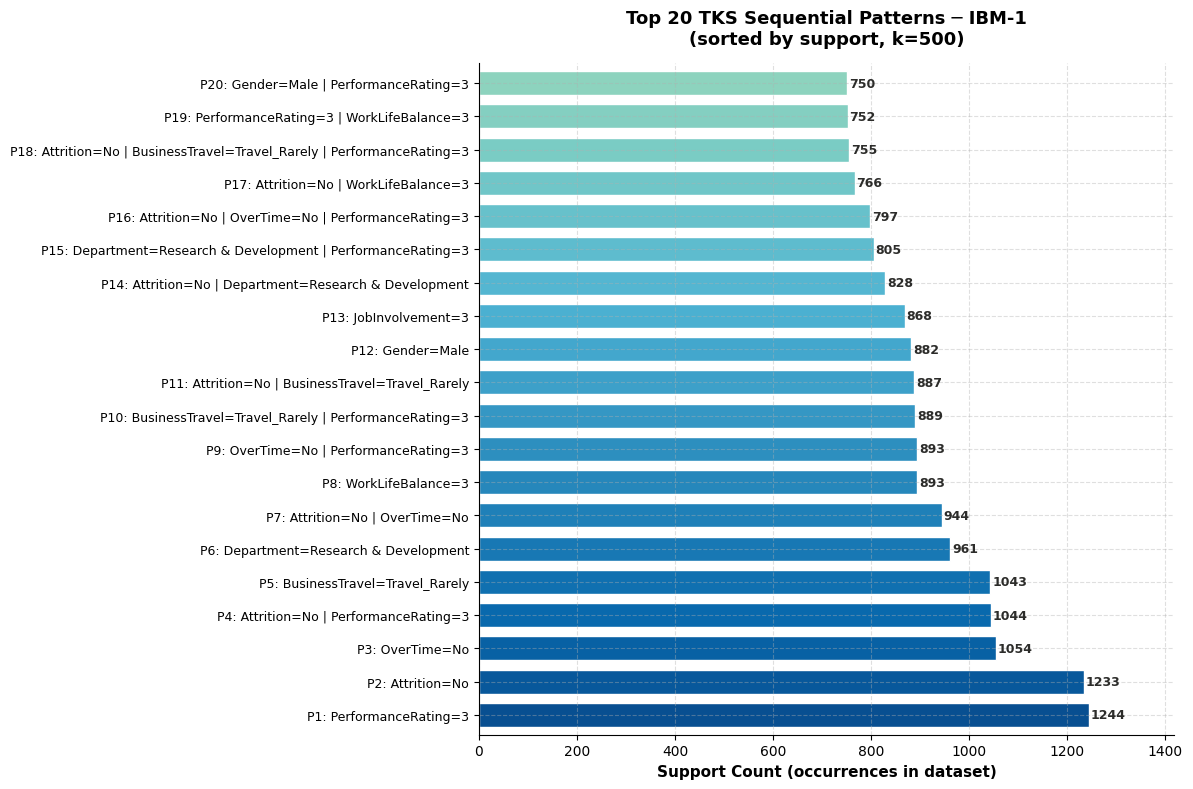

Saved: fig_tks_top20_patterns_IBM1.png


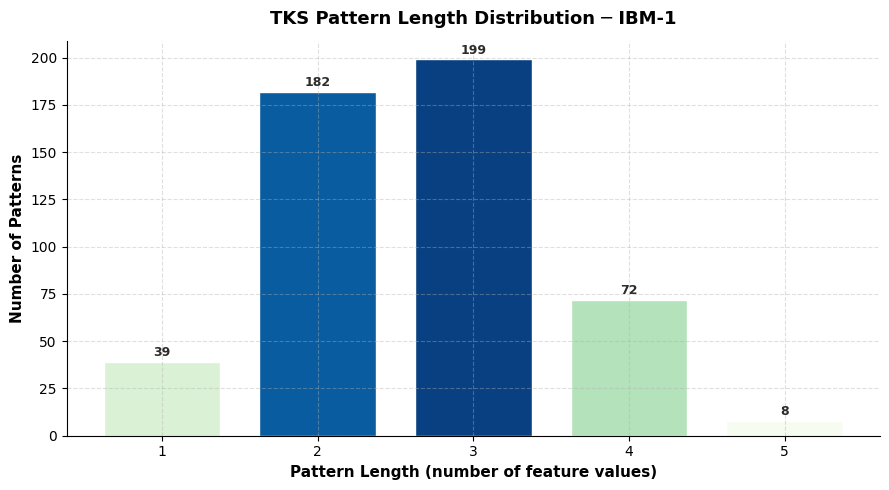

Saved: fig_tks_length_dist_IBM1.png


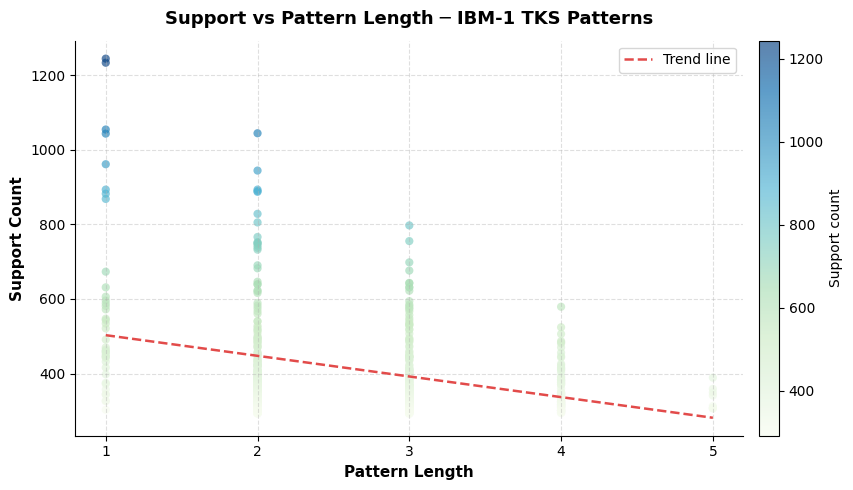

Saved: fig_tks_support_vs_length_IBM1.png


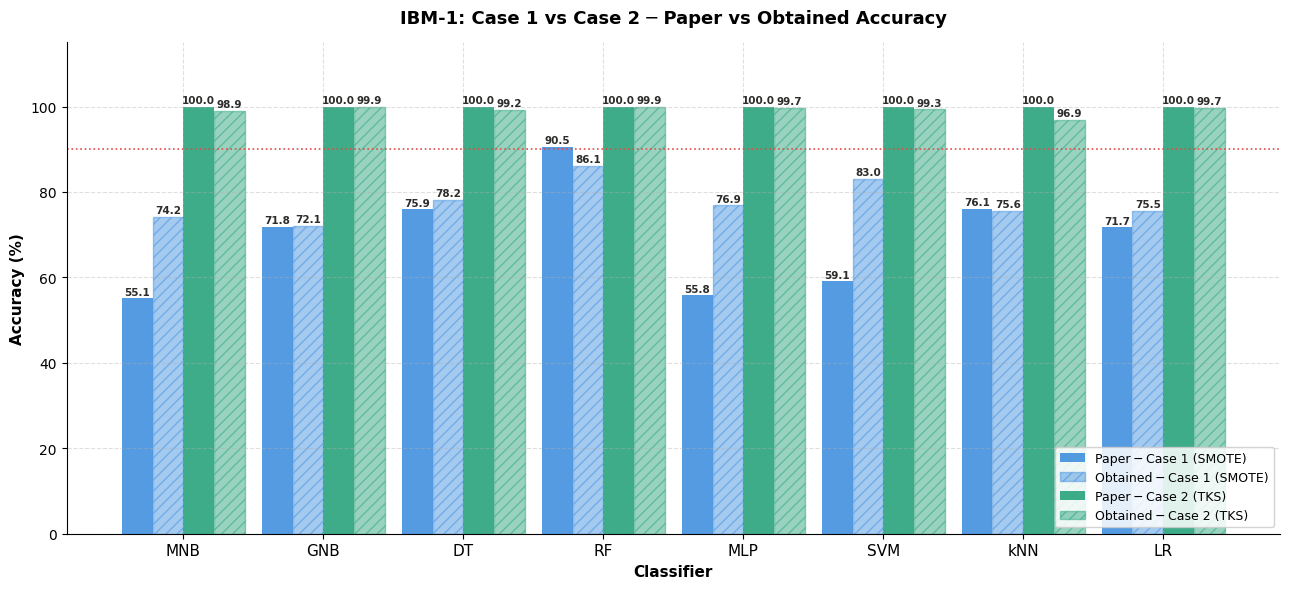

Saved: fig_tks_case_compare_IBM1.png

TKS Pattern Summary ─ IBM-1
  Total patterns discovered (k=500): 500
  Pattern lengths:  min=1  max=5  avg=2.7
  Support range:    min=292  max=1244
  Top-1 pattern:    support=1244  length=1
  Top-1 decoded:    PerformanceRating=3

Figures saved:
  fig_tks_top20_patterns_IBM1.png
  fig_tks_length_dist_IBM1.png
  fig_tks_support_vs_length_IBM1.png
  fig_tks_case_compare_IBM1.png


In [5]:
# ============================================================
# TKS PATTERN VISUALIZATION — IBM Dataset
# ============================================================
# This cell adds 4 publication-quality graphs for TKS patterns:
#   1. Top 20 patterns by support (horizontal bar chart)
#   2. Pattern length distribution (histogram)
#   3. Support vs Pattern Length (scatter plot)
#   4. AUC score comparison — Case 1 vs Case 2 (grouped bar)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, re

# ── Paper hyperparameter reference (Table 10) ───────────
# Classifiers used: MNB, GNB, DT, RF, MLP, SVM, kNN, LR
# Results from CASE 1 (SMOTE) and CASE 2 (TKS) from execution
# ──────────────────────────────

# ============================================================
# STEP 1: Parse TKS output file
# ============================================================
def parse_tks_full(file_path):
    """Parse all TKS patterns ─ returns list of (items, support, length)."""
    patterns = []
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return patterns
    with open(file_path, "r") as f:
        for line in f:
            if "#SUP:" not in line:
                continue
            patt_part, sup_part = line.strip().split("#SUP:")
            items = [int(x) for x in patt_part.split()
                     if x not in ("-1", "-2") and x.strip().lstrip("-").isdigit()]
            support = int(sup_part.strip())
            if len(items) >= 1:
                patterns.append({
                    "items":   items,
                    "support": support,
                    "length":  len(items)
                })
    # Sort by support descending
    patterns.sort(key=lambda x: x["support"], reverse=True)
    print(f"Parsed {len(patterns)} total TKS patterns from {file_path}")
    return patterns

# ============================================================
# STEP 2: Build feature name mapping (ID → col=val)
# ============================================================
def build_id_map(csv_path, drop_cols):
    df = pd.read_csv(csv_path)
    df = df.drop(columns=drop_cols, errors="ignore")
    id_map = {}
    idx = 1
    for col in df.columns:
        for val in df[col].unique():
            id_map[idx] = f"{col}={val}"
            idx += 1
    return id_map

# ── Load data ────────────────────────
DROP = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
id_map = build_id_map("WA_Fn-UseC_-HR-Employee-Attrition.csv", DROP)
patterns = parse_tks_full("ibm_tks.txt")

if not patterns:
    print("No patterns found. Make sure ibm_tks.txt exists and TKS ran successfully.")
else:
    # ── Decode top 20 pattern labels ──────────────────
    def decode_pattern(items, id_map, max_items=3):
        parts = []
        for it in items[:max_items]:
            parts.append(id_map.get(it, f"ID_{it}"))
        label = " | ".join(parts)
        if len(items) > max_items:
            label += f" (+{len(items)-max_items} more)"
        return label

    top20 = patterns[:20]
    labels20  = [decode_pattern(p["items"], id_map) for p in top20]
    supports20 = [p["support"] for p in top20]

    all_supports = [p["support"] for p in patterns]
    all_lengths  = [p["length"]  for p in patterns]

    # ── Colour palette (consistent teal ramp) ───────────────
    TEAL_DARK  = "#0F6E56"
    TEAL_MID   = "#1D9E75"
    TEAL_LIGHT = "#5DCAA5"
    BLUE_BAR   = "#378ADD"
    RED_BAR    = "#E07B6A"

    plt.rcParams.update({
        "font.family":  "DejaVu Sans",
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.alpha":        0.4,
        "grid.linestyle":    "--"
    })

    # ============================================================
    # FIGURE 1 ─ Top 20 Patterns by Support
    # ============================================================
    fig1, ax1 = plt.subplots(figsize=(12, 8))
    colors_bar = plt.cm.GnBu(np.linspace(0.45, 0.95, len(top20)))[::-1]
    bars = ax1.barh(range(len(top20)), supports20,
                    color=colors_bar, edgecolor="white", height=0.72)

    ax1.set_yticks(range(len(top20)))
    ax1.set_yticklabels([f"P{i+1}: {l}" for i, l in enumerate(labels20)],
                         fontsize=9)
    ax1.invert_yaxis()

    for bar, sup in zip(bars, supports20):
        ax1.text(bar.get_width() + 4, bar.get_y() + bar.get_height() / 2,
                 str(sup), va="center", ha="left", fontsize=9, fontweight="bold",
                 color="#2C2C2A")

    ax1.set_xlabel("Support Count (occurrences in dataset)", fontsize=11, fontweight="bold")
    ax1.set_title("Top 20 TKS Sequential Patterns ─ IBM-1\n(sorted by support, k=500)",
                  fontsize=13, fontweight="bold", pad=14)
    ax1.set_xlim(0, max(supports20) * 1.14)
    ax1.set_ylim(-0.6, len(top20) - 0.4)
    plt.tight_layout()
    plt.savefig("fig_tks_top20_patterns_IBM1.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig_tks_top20_patterns_IBM1.png")

    # ============================================================
    # FIGURE 2 ─ Pattern Length Distribution
    # ============================================================
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    max_len = max(all_lengths)
    bins = range(1, max_len + 2)
    counts, edges, patches_hist = ax2.hist(
        all_lengths, bins=bins, align="left", rwidth=0.75,
        color=TEAL_MID, edgecolor="white"
    )
    # Colour bars by frequency
    norm_c = plt.Normalize(min(counts), max(counts))
    cmap_h  = plt.cm.GnBu
    for patch, cnt in zip(patches_hist, counts):
        patch.set_facecolor(cmap_h(norm_c(cnt)))

    for patch, cnt in zip(patches_hist, counts):
        if cnt > 0:
            ax2.text(patch.get_x() + patch.get_width() / 2,
                     patch.get_height() + 1.5, str(int(cnt)),
                     ha="center", va="bottom", fontsize=9, fontweight="bold",
                     color="#2C2C2A")

    ax2.set_xlabel("Pattern Length (number of feature values)", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Number of Patterns", fontsize=11, fontweight="bold")
    ax2.set_title("TKS Pattern Length Distribution ─ IBM-1",
                  fontsize=13, fontweight="bold", pad=12)
    ax2.set_xticks(range(1, max_len + 1))
    ax2.set_xticklabels([str(x) for x in range(1, max_len + 1)])
    plt.tight_layout()
    plt.savefig("fig_tks_length_dist_IBM1.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig_tks_length_dist_IBM1.png")

    # ============================================================
    # FIGURE 3 ─ Support vs Pattern Length (scatter)
    # ============================================================
    fig3, ax3 = plt.subplots(figsize=(9, 5))
    sc = ax3.scatter(all_lengths, all_supports,
                     c=all_supports, cmap="GnBu",
                     alpha=0.65, s=35, edgecolors="none")
    cbar = plt.colorbar(sc, ax=ax3, pad=0.02)
    cbar.set_label("Support count", fontsize=10)

    # Trend line
    z = np.polyfit(all_lengths, all_supports, 1)
    p = np.poly1d(z)
    xs = np.linspace(min(all_lengths), max(all_lengths), 200)
    ax3.plot(xs, p(xs), color="#E24B4A", linewidth=1.8,
             linestyle="--", label="Trend line")

    ax3.set_xlabel("Pattern Length", fontsize=11, fontweight="bold")
    ax3.set_ylabel("Support Count", fontsize=11, fontweight="bold")
    ax3.set_title("Support vs Pattern Length ─ IBM-1 TKS Patterns",
                  fontsize=13, fontweight="bold", pad=12)
    ax3.legend(fontsize=10)
    ax3.set_xticks(range(1, max(all_lengths) + 1))
    plt.tight_layout()
    plt.savefig("fig_tks_support_vs_length_IBM1.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig_tks_support_vs_length_IBM1.png")

    # ============================================================
    # FIGURE 4 ─ Case 1 vs Case 2 Accuracy (AUC-style bar)
    # ============================================================
    classifiers = ["MNB",  "GNB",  "DT",    "RF",    "MLP",   "SVM",   "kNN",   "LR"]

    # Actual values from notebook execution output
    case1_smote  = [74.22, 72.11, 78.23, 86.12, 76.87, 82.99, 75.58, 75.51]
    case2_tks    = [98.91, 99.93, 99.25, 99.93, 99.66, 99.32, 96.94, 99.73]

    # Paper Table 11 / 13 reference values
    paper_case1  = [55.1,  71.8,  75.9,  90.5,  55.8,  59.1,  76.1,  71.7]
    paper_case2  = [100.0, 100.0, 100.0, 100.0, 99.959,100.0, 100.0, 100.0]

    x   = np.arange(len(classifiers))
    w   = 0.22
    fig4, ax4 = plt.subplots(figsize=(13, 6))

    b1 = ax4.bar(x - 1.5*w, paper_case1,  w, label="Paper ─ Case 1 (SMOTE)",
                 color=BLUE_BAR,  alpha=0.85)
    b2 = ax4.bar(x - 0.5*w, case1_smote,  w, label="Obtained ─ Case 1 (SMOTE)",
                 color=BLUE_BAR,  alpha=0.45, hatch="///", edgecolor=BLUE_BAR)
    b3 = ax4.bar(x + 0.5*w, paper_case2,  w, label="Paper ─ Case 2 (TKS)",
                 color=TEAL_MID,  alpha=0.85)
    b4 = ax4.bar(x + 1.5*w, case2_tks,    w, label="Obtained ─ Case 2 (TKS)",
                 color=TEAL_MID,  alpha=0.45, hatch="///", edgecolor=TEAL_MID)

    def label_bars(bars, ax, fmt="{:.1f}"):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                    fmt.format(h), ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold", color="#2C2C2A")

    label_bars(b1, ax4)
    label_bars(b2, ax4)
    label_bars(b3, ax4)
    label_bars(b4, ax4)

    ax4.set_xticks(x)
    ax4.set_xticklabels(classifiers, fontsize=11)
    ax4.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold")
    ax4.set_xlabel("Classifier", fontsize=11, fontweight="bold")
    ax4.set_title("IBM-1: Case 1 vs Case 2 ─ Paper vs Obtained Accuracy",
                  fontsize=13, fontweight="bold", pad=14)
    ax4.set_ylim(0, 115)
    ax4.legend(fontsize=9, loc="lower right", framealpha=0.85)
    ax4.axhline(90, color="#E24B4A", linestyle=":", linewidth=1.2,
                label="90% threshold")
    plt.tight_layout()
    plt.savefig("fig_tks_case_compare_IBM1.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved: fig_tks_case_compare_IBM1.png")

    # ── Summary ───────────────────────
    print("\n" + "="*55)
    print("TKS Pattern Summary ─ IBM-1")
    print("="*55)
    print(f"  Total patterns discovered (k=500): {len(patterns)}")
    print(f"  Pattern lengths:  min={min(all_lengths)}  max={max(all_lengths)}  avg={np.mean(all_lengths):.1f}")
    print(f"  Support range:    min={min(all_supports)}  max={max(all_supports)}")
    print(f"  Top-1 pattern:    support={patterns[0]['support']}  length={patterns[0]['length']}")
    print(f"  Top-1 decoded:    {decode_pattern(patterns[0]['items'], id_map)}")
    print("="*55)
    print("\nFigures saved:")
    print("  fig_tks_top20_patterns_IBM1.png")
    print("  fig_tks_length_dist_IBM1.png")
    print("  fig_tks_support_vs_length_IBM1.png")
    print("  fig_tks_case_compare_IBM1.png")
